## Importing Packages

In [1]:
import fastf1
import fastf1.plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

fastf1.plotting.setup_mpl()

## Loading Session Data

In [2]:
year = 2019
race = "United States Grand Prix"

session = fastf1.get_session(year, race, 'R')
session.load()

req         WARNING 	DEFAULT CACHE ENABLED! (2.26 GB) C:\Users\odath\AppData\Local\Temp\fastf1
core           INFO 	Loading data for United States Grand Prix - Race [v3.7.0]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching

## Loading and Preparing Lap Data

In [3]:
laps = session.laps
laps = laps.sort_values(['Driver', 'LapNumber'])
laps['LapTimeSeconds'] = laps['LapTime'].dt.total_seconds()
laps.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate,LapTimeSeconds
273,0 days 00:35:13.270000,ALB,23,0 days 00:01:49.520000,1.0,1.0,NaT,0 days 00:35:12.368000,NaT,0 days 00:00:42.707000,...,Red Bull Racing,0 days 00:33:23.612000,2019-11-03 19:13:24.328,1,11.0,False,,False,False,109.520
274,0 days 00:37:23.778000,ALB,23,0 days 00:02:10.508000,2.0,2.0,0 days 00:35:46.479000,NaT,0 days 00:00:57.704000,0 days 00:00:40.282000,...,Red Bull Racing,0 days 00:35:13.270000,2019-11-03 19:15:13.986,1,20.0,False,,False,False,130.508
275,0 days 00:39:03.933000,ALB,23,0 days 00:01:40.155000,3.0,2.0,NaT,NaT,0 days 00:00:27.283000,0 days 00:00:40.178000,...,Red Bull Racing,0 days 00:37:23.778000,2019-11-03 19:17:24.494,1,20.0,False,,False,True,100.155
276,0 days 00:40:44.310000,ALB,23,0 days 00:01:40.377000,4.0,2.0,NaT,NaT,0 days 00:00:27.255000,0 days 00:00:40.358000,...,Red Bull Racing,0 days 00:39:03.933000,2019-11-03 19:19:04.649,1,20.0,False,,False,True,100.377
277,0 days 00:42:24.708000,ALB,23,0 days 00:01:40.398000,5.0,2.0,NaT,NaT,0 days 00:00:27.063000,0 days 00:00:40.408000,...,Red Bull Racing,0 days 00:40:44.310000,2019-11-03 19:20:45.026,1,20.0,False,,False,True,100.398


## Compound color map

In [4]:
COMPOUND_COLORS = {
    'SOFT': '#FF3333',
    'MEDIUM': '#FFD700',
    'HARD': "#C6BFBF",
    'INTERMEDIATE': '#39B54A',
    'WET': '#0077FF'
}

## Race Statergy Comparison between different drivers

In [5]:
results = session.results
dnf_drivers = session.results[
    (session.results['Position'].isna()) |
    (session.results['Status'].str.contains('Crash|Accident|Engine|Retired|Gearbox|Did not start|Mechanical|Collision damage|Disqualified|Hydraulics|Exhaust|Suspension|Overheating|Power Unit|Battery', na=False))
]['Abbreviation'].tolist()

session.results['Status'].head(22)

77      Finished
44      Finished
33      Finished
16      Finished
23      Finished
3       Finished
4       Finished
55        +1 Lap
27        +1 Lap
11        +1 Lap
7         +1 Lap
26        +1 Lap
18        +1 Lap
99        +1 Lap
8         +1 Lap
10    Suspension
63       +2 Laps
20        Brakes
88      Oil leak
5     Suspension
Name: Status, dtype: object

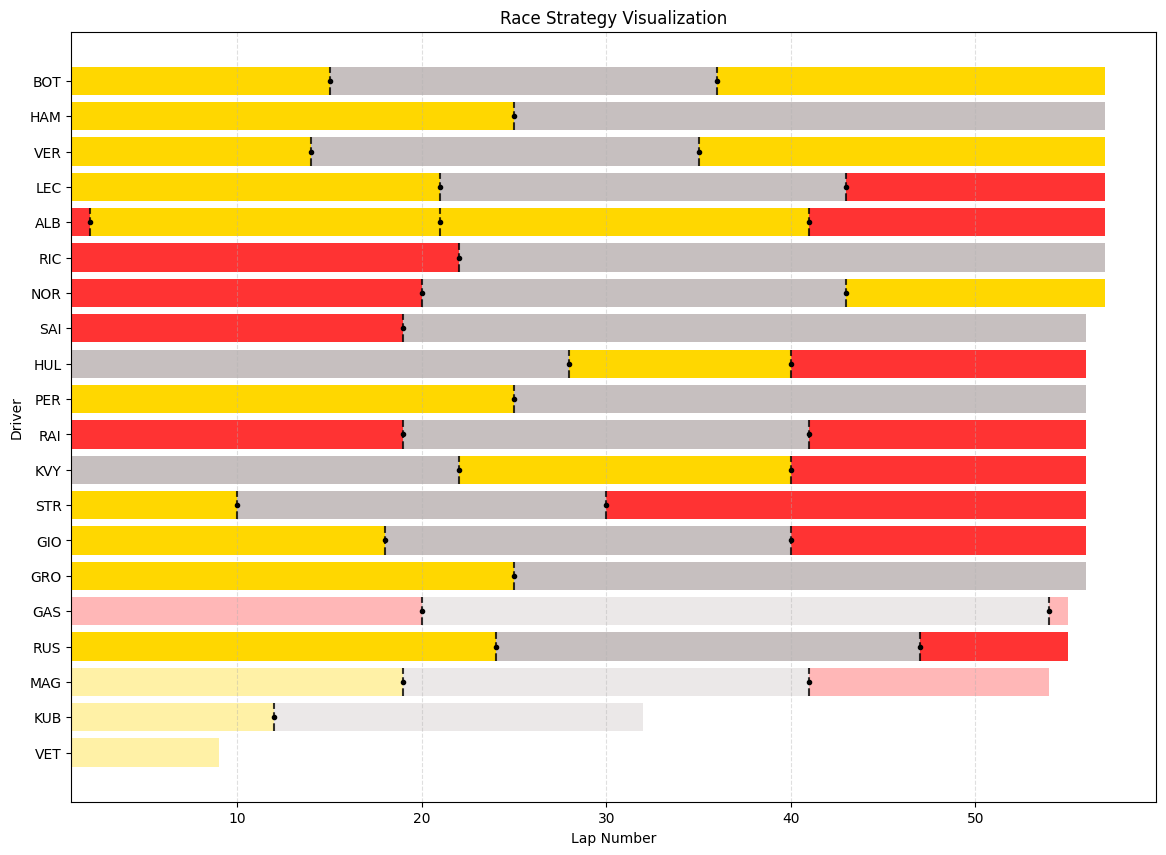

In [6]:
# Get finishing order
finishing_order = session.results.sort_values('Position')['Abbreviation'].tolist()
drivers = finishing_order[::-1]  # P1 at bottom

results = session.results
dnf_drivers = session.results[
    (session.results['Position'].isna()) |
    (session.results['Status'].str.contains('Oil leak|Water pressure|Power Unit|Suspension|Brakes|Collision|Accident|Engine|Retired|Gearbox|Did not start|Collision damage|Mechanical|Disqualified|Hydraulics|Exhaust|Suspension|Overheating|Power Unit|Battery', na=False))
]['Abbreviation'].tolist()


y_positions = {driver: i for i, driver in enumerate(drivers)}

fig, ax = plt.subplots(figsize=(14,10))

for driver in drivers:
    driver_laps = laps[laps['Driver'] == driver]
    stints = driver_laps.groupby('Stint')

    alpha = 0.35 if driver in dnf_drivers else 1.0
    y = y_positions[driver]

    for stint, data in stints:
        compound = data['Compound'].mode()[0]
        width = data['LapNumber'].max() - data['LapNumber'].min() + 1

        ax.barh(
            y,
            width,
            left=data['LapNumber'].min(),
            color=COMPOUND_COLORS.get(compound, '#AAAAAA'),
            alpha=alpha
        )

    # Pit stop markers
    pit_laps = driver_laps.loc[
        driver_laps['Stint'].diff() == 1, 'LapNumber'
    ]

    for lap in pit_laps:
        ax.plot(lap, y, marker='o', color='black', markersize=3, zorder=6)
        ax.vlines(
            lap,
            y - 0.4,
            y + 0.4,
            colors='black',
            linestyles='dashed',
            linewidth=1.5,
            alpha=0.8,
            zorder=5
        )

# Fix y-axis labels
ax.set_yticks(range(len(drivers)))
ax.set_yticklabels(drivers)

ax.set_xlabel("Lap Number")
ax.set_ylabel("Driver")
ax.set_title("Race Strategy Visualization")
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.show()